<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/13wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-yrjHdxcPq2gOxDotiCasBg&si=e2T7XSxvVyTFsjdi>}}

# 2. Imports

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

# 3. FashionMNIST

## A. 평범한 학습

`-` 데이터

In [4]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,transform=torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True,transform=torchvision.transforms.ToTensor())
X,y = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=60000)))
XX,yy = next(iter(torch.utils.data.DataLoader(test_dataset,batch_size=10000)))

`-` 2d를 처리하는 네트워크

In [13]:
net1 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Flatten()
)

In [14]:
net1(X).shape

torch.Size([60000, 2304])

`-` 1d를 처리하는 네트워크

In [16]:
net2 = torch.nn.Sequential(
    torch.nn.Linear(2304,10)
)

In [18]:
net2(net1(X)).shape

torch.Size([60000, 10])

`-` 두 네트워크를 결합

In [20]:
net = torch.nn.Sequential(
    net1,
    net2
)
net(X).shape

torch.Size([60000, 10])

`-` 최종적인 코드

In [21]:
X = X.to("cuda:0")
y = y.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Flatten(),
    torch.nn.Linear(2304,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#----#
for epoch in range(100):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [26]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.8526, device='cuda:0')

In [28]:
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.8416, device='cuda:0')

## B. val 이용

In [29]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,transform=torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True,transform=torchvision.transforms.ToTensor())

In [39]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [45]:
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])

In [48]:
len(train_dataset), len(valid_dataset)

(48000, 12000)

In [64]:
X,y = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=48000)))
XX,yy = next(iter(torch.utils.data.DataLoader(valid_dataset,batch_size=12000)))
XXX,yyy = next(iter(torch.utils.data.DataLoader(test_dataset,batch_size=10000)))

`-` 학습해보자.

In [74]:
X = X.to("cuda:0")
y = y.to("cuda:0")
XX = XX.to("cuda:0")
yy = yy.to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Flatten(),
    torch.nn.Linear(2304,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#----#
for epoch in range(100):
    # step1
    Logits = net(X)
    # step2
    loss = loss_fn(Logits,y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()
    # 기다리기 심심하니까..
    if (epoch+1) % 5 ==0:
        train_acc = (net(X).argmax(axis=1) ==y).float().mean()
        val_acc = (net(XX).argmax(axis=1) ==yy).float().mean()
        print(f"epoch = {epoch+1} / train acc = {train_acc:.4f} / val acc = {val_acc:.4f}")

epoch = 5 / train acc = 0.6593 / val acc = 0.6544
epoch = 10 / train acc = 0.7043 / val acc = 0.6964
epoch = 15 / train acc = 0.7186 / val acc = 0.7111
epoch = 20 / train acc = 0.7354 / val acc = 0.7271
epoch = 25 / train acc = 0.7470 / val acc = 0.7375
epoch = 30 / train acc = 0.7583 / val acc = 0.7493
epoch = 35 / train acc = 0.7704 / val acc = 0.7586
epoch = 40 / train acc = 0.7821 / val acc = 0.7747
epoch = 45 / train acc = 0.7928 / val acc = 0.7871
epoch = 50 / train acc = 0.8031 / val acc = 0.7988
epoch = 55 / train acc = 0.8118 / val acc = 0.8054
epoch = 60 / train acc = 0.8200 / val acc = 0.8133
epoch = 65 / train acc = 0.8273 / val acc = 0.8171
epoch = 70 / train acc = 0.8330 / val acc = 0.8223
epoch = 75 / train acc = 0.8372 / val acc = 0.8265
epoch = 80 / train acc = 0.8408 / val acc = 0.8313
epoch = 85 / train acc = 0.8439 / val acc = 0.8359
epoch = 90 / train acc = 0.8477 / val acc = 0.8388
epoch = 95 / train acc = 0.8519 / val acc = 0.8427
epoch = 100 / train acc = 0.8551

In [75]:
net.to("cpu")

Sequential(
  (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=2304, out_features=10, bias=True)
)

In [79]:
(net(XXX).argmax(axis=1) == yyy).float().mean()

tensor(0.8428)

`-` 질문!! 교수님 이렇게 코드짜면 안되나요?

```python
for epoch in range(100):
    net.to("cuda:0")
    # step1
    # step2
    # step3
    # step4
    # 기다리기 심심하니까..
    net.to("cpu")
```

- 안돼요. net의 파라메터는 (가능하면) 지박령마냥 cuda에 계속있는게 좋아요.

# 4. CIFAR10

## A. 데이터

In [2]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,transform=torchvision.transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,transform=torchvision.transforms.ToTensor())

In [3]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [4]:
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8,0.2])

In [5]:
X,y = next(iter(torch.utils.data.DataLoader(train_dataset,batch_size=40000,shuffle=True)))
XX,yy = next(iter(torch.utils.data.DataLoader(valid_dataset,batch_size=10000,shuffle=True)))
XXX,yyy = next(iter(torch.utils.data.DataLoader(test_dataset,batch_size=10000,shuffle=True)))

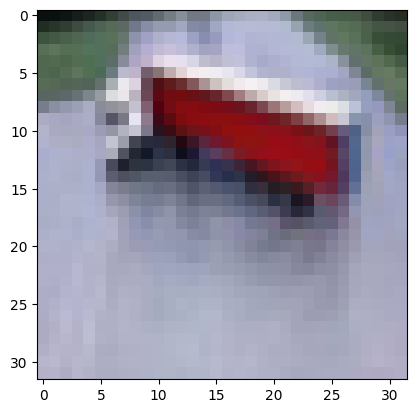

In [103]:
# plt.imshow(X[0].reshape(32,32,3)) # 잘못된코드
plt.imshow(X[0].permute(1,2,0))

- 이게뭐야?

In [104]:
y[0]

tensor(9)

In [97]:
test_dataset.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

## B. 내가 직접 net설계

In [6]:
ds_train = torch.utils.data.TensorDataset(X,y)
# ds_val = torch.utils.data.TensorDataset(XX,yy) # 굳이?
# ds_test = torch.utils.data.TensorDataset(XXX,yyy) # 굳이?
dl_train = torch.utils.data.DataLoader(ds_train,batch_size=200,shuffle=True)
# dl_val = torch.utils.data.DataLoader(ds_val,batch_size=200,shuffle=False) # 굳이?
# dl_test = torch.utils.data.DataLoader(ds_test,batch_size=200,shuffle=False) # 굳이?

In [13]:
net = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    #---#
    torch.nn.Linear(4608,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(200):
    for Xm,ym in dl_train:
        Xm = Xm.to("cuda:0")
        ym = ym.to("cuda:0")
        #step1
        Logits = net(Xm)
        #step2
        loss = loss_fn(Logits,ym)
        #step3
        loss.backward()
        #step4
        optimizer.step()
        optimizer.zero_grad()

In [14]:
net.to("cpu")

Sequential(
  (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=4608, out_features=10, bias=True)
)

In [15]:
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9847)

In [16]:
(net(XX).argmax(axis=1) == yy).float().mean()

tensor(0.5991)

In [17]:
(net(XXX).argmax(axis=1) == yyy).float().mean()

tensor(0.5938)

`-` 그런데... train_acc 를 아래와 같이 계산할 수도 있다.

In [25]:
total = 0
correct = 0
for Xm,ym in dl_train:
    total = total + len(ym)
    correct = correct + (net(Xm).argmax(axis=1) == ym).sum()
acc = correct/total
acc.item()

0.9846749901771545

`-` 에폭중 train_acc와 val_acc를 함께 찍어보자. (뭐 어쩌다 저지경까지 간건지 궁금하기도 하고.. 심심하기도 하고.. 겸사겸사..)

In [26]:
ds_train = torch.utils.data.TensorDataset(X,y)
ds_val = torch.utils.data.TensorDataset(XX,yy) # 굳이!
# ds_test = torch.utils.data.TensorDataset(XXX,yyy) # 굳이?
dl_train = torch.utils.data.DataLoader(ds_train,batch_size=200,shuffle=True)
dl_val = torch.utils.data.DataLoader(ds_val,batch_size=200,shuffle=False) # 굳이!
# dl_test = torch.utils.data.DataLoader(ds_test,batch_size=200,shuffle=False) # 굳이?

In [27]:
net = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=3,out_channels=32,kernel_size=5),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2),
    torch.nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3),
    torch.nn.ReLU(),
    torch.nn.Flatten(),
    #---#
    torch.nn.Linear(4608,10)
).to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(200):
    for Xm,ym in dl_train:
        Xm = Xm.to("cuda:0")
        ym = ym.to("cuda:0")
        #step1
        Logits = net(Xm)
        #step2
        loss = loss_fn(Logits,ym)
        #step3
        loss.backward()
        #step4
        optimizer.step()
        optimizer.zero_grad()
    # 기다리기 심심하니까..
    if (epoch+1) % 20 ==0:
        # train_acc
        total = 0
        correct = 0
        for Xm,ym in dl_train:
            Xm = Xm.to("cuda:0")
            ym = ym.to("cuda:0")
            total = total + len(ym)
            correct = correct + (net(Xm).argmax(axis=1) == ym).sum()
        train_acc = correct/total
        # val_acc
        total = 0
        correct = 0
        for XXm,yym in dl_val:
            XXm = XXm.to("cuda:0")
            yym = yym.to("cuda:0")
            total = total + len(yym)
            correct = correct + (net(XXm).argmax(axis=1) == yym).sum()
        val_acc = correct/total
        print(f"epoch = {epoch+1} / train acc = {train_acc:.4f} / val acc = {val_acc:.4f}")

epoch = 20 / train acc = 0.7467 / val acc = 0.6617
epoch = 40 / train acc = 0.8176 / val acc = 0.6593
epoch = 60 / train acc = 0.8672 / val acc = 0.6450
epoch = 80 / train acc = 0.8973 / val acc = 0.6259
epoch = 100 / train acc = 0.9037 / val acc = 0.6156
epoch = 120 / train acc = 0.9380 / val acc = 0.6112
epoch = 140 / train acc = 0.9634 / val acc = 0.6049
epoch = 160 / train acc = 0.9704 / val acc = 0.6040
epoch = 180 / train acc = 0.9766 / val acc = 0.6011
epoch = 200 / train acc = 0.9905 / val acc = 0.6024


`-` test_acc 를 알고싶은데 `net.to("cpu")` 하지말고 그냥 아래와 같이 할까?

In [38]:
def accuracy(net,dl):
    total = 0
    correct = 0
    with torch.no_grad():
        for imgs,lbls in dl:
            imgs = imgs.to("cuda:0")
            lbls = lbls.to("cuda:0")
            total = total + len(lbls)
            correct = correct + (net(imgs).argmax(axis=1) == lbls).sum()
    acc = correct/total
    return acc.item()

In [39]:
ds_test = torch.utils.data.TensorDataset(XXX,yyy) # 굳이!
dl_test = torch.utils.data.DataLoader(ds_test,batch_size=200,shuffle=False) # 굳이!

In [41]:
accuracy(net,dl_train)

0.9905499815940857

## C. `resnet18`

`-` ref: <https://arxiv.org/pdf/1512.03385>

In [96]:
ds_train = torch.utils.data.TensorDataset(X,y)
ds_val = torch.utils.data.TensorDataset(XX,yy) # 굳이!
ds_test = torch.utils.data.TensorDataset(XXX,yyy) # 굳이!
dl_train = torch.utils.data.DataLoader(ds_train,batch_size=200,shuffle=True)
dl_val = torch.utils.data.DataLoader(ds_val,batch_size=200,shuffle=False) # 굳이!
dl_test = torch.utils.data.DataLoader(ds_test,batch_size=200,shuffle=False) # 굳이!
#---#
net = torchvision.models.resnet18()
net.fc = torch.nn.Linear(in_features=512, out_features=10, bias=True)
net.to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(50):
    for Xm,ym in dl_train:
        Xm = Xm.to("cuda:0")
        ym = ym.to("cuda:0")
        #step1
        Logits = net(Xm)
        #step2
        loss = loss_fn(Logits,ym)
        #step3
        loss.backward()
        #step4
        optimizer.step()
        optimizer.zero_grad()
    # 기다리기 심심하니까..
    if (epoch+1) % 5 ==0:
        net.eval()
        train_acc = accuracy(net,dl_train)
        val_acc = accuracy(net,dl_val)
        print(f"epoch = {epoch+1} / train acc = {train_acc:.4f} / val acc = {val_acc:.4f}")
        net.train()

epoch = 5 / train acc = 0.7461 / val acc = 0.6511
epoch = 10 / train acc = 0.8914 / val acc = 0.6904
epoch = 15 / train acc = 0.9528 / val acc = 0.7190
epoch = 20 / train acc = 0.9543 / val acc = 0.7065
epoch = 25 / train acc = 0.9073 / val acc = 0.6742
epoch = 30 / train acc = 0.9695 / val acc = 0.7201
epoch = 35 / train acc = 0.9525 / val acc = 0.7126
epoch = 40 / train acc = 0.9647 / val acc = 0.7124
epoch = 45 / train acc = 0.9751 / val acc = 0.7197
epoch = 50 / train acc = 0.9783 / val acc = 0.7202


## D. `resnet18`, pretrained=True

`-` 이걸 트랜스퍼러닝이라고함.

In [116]:
ds_train = torch.utils.data.TensorDataset(X,y)
ds_val = torch.utils.data.TensorDataset(XX,yy) # 굳이!
ds_test = torch.utils.data.TensorDataset(XXX,yyy) # 굳이!
dl_train = torch.utils.data.DataLoader(ds_train,batch_size=200,shuffle=True)
dl_val = torch.utils.data.DataLoader(ds_val,batch_size=200,shuffle=False) # 굳이!
dl_test = torch.utils.data.DataLoader(ds_test,batch_size=200,shuffle=False) # 굳이!
#---#
net = torchvision.models.resnet18(pretrained=True)
net.fc = torch.nn.Linear(in_features=512, out_features=10, bias=True)
net.to("cuda:0")
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(50):
    for Xm,ym in dl_train:
        Xm = Xm.to("cuda:0")
        ym = ym.to("cuda:0")
        #step1
        Logits = net(Xm)
        #step2
        loss = loss_fn(Logits,ym)
        #step3
        loss.backward()
        #step4
        optimizer.step()
        optimizer.zero_grad()
    # 기다리기 심심하니까..
    if (epoch+1) % 5 ==0:
        net.eval()
        train_acc = accuracy(net,dl_train)
        val_acc = accuracy(net,dl_val)
        print(f"epoch = {epoch+1} / train acc = {train_acc:.4f} / val acc = {val_acc:.4f}")
        net.train()

epoch = 5 / train acc = 0.9188 / val acc = 0.7825
epoch = 10 / train acc = 0.9691 / val acc = 0.8041
epoch = 15 / train acc = 0.9834 / val acc = 0.8063
epoch = 20 / train acc = 0.9892 / val acc = 0.8130
epoch = 25 / train acc = 0.9872 / val acc = 0.8104
epoch = 30 / train acc = 0.9478 / val acc = 0.7607
epoch = 35 / train acc = 0.9921 / val acc = 0.8074
epoch = 40 / train acc = 0.9357 / val acc = 0.7565
epoch = 45 / train acc = 0.9909 / val acc = 0.8032
epoch = 50 / train acc = 0.9908 / val acc = 0.7996


- 성능이 좋음

`-` 사실 생각해보면 뭐 그렇게 신기한것도 아님. 어차피 2D파트는 필터설계인데, "AI가 이전에 설계한 필터들을 그대로 쓴다" 라는 관점으로 보면 이해가 쉬움.

# 5. OxfordIIITPet

## A. 데이터

In [121]:
train_dataset = torchvision.datasets.OxfordIIITPet(
  root='./data', split='trainval',
  target_types="binary-category",
  transform = None,
  download=True
)
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8,0.2])
test_dataset = torchvision.datasets.OxfordIIITPet(
  root='./data', split='test',
  target_types="binary-category",
  transform = None,
  download=True
)

100%|██████████| 792M/792M [00:44<00:00, 17.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]


In [131]:
train_dataset[2][1]

0

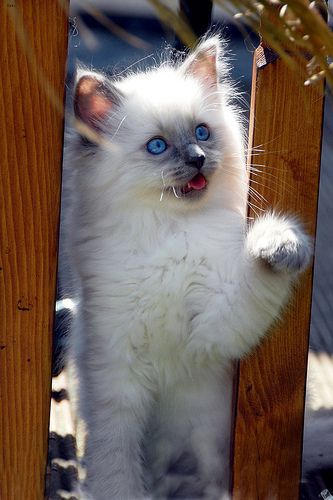

In [132]:
train_dataset[2][0]

In [135]:
len(train_dataset), len(valid_dataset), len(test_dataset)

(2944, 736, 3669)

- 0: 고양이
- 1: 강아지

`-` `train_dataset[2][0]` 은 정체가 뭐지? (왜 이미지가 바로나오지?)

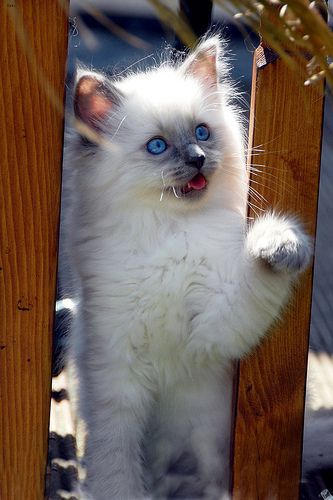

In [140]:
train_dataset[2][0] # 이미지가 바로 보여서 좋기는 한데, 숫자가 안보임

`-` 숫자화시키고 싶다.

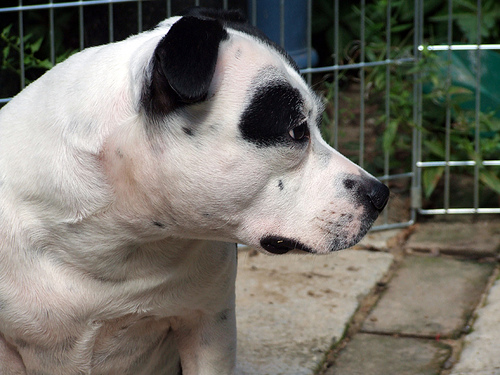

In [150]:
img = train_dataset[3][0]
img

In [151]:
to_tensor = torchvision.transforms.ToTensor()

torch.Size([3, 375, 500])


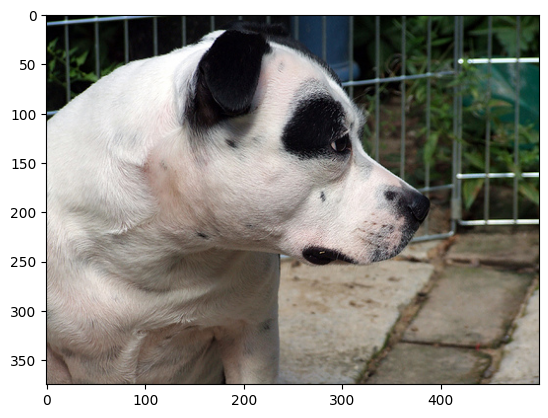

In [153]:
plt.imshow(to_tensor(img).permute(1,2,0))
print(to_tensor(img).shape)

- 숫자화시킨건 좋은데, 이미지의 크기가 제각각이겠네?

`-` 이미지의 크기도 통일시켜보자.

In [159]:
resize = torchvision.transforms.Resize([224,224])
resize

Resize(size=[224, 224], interpolation=bilinear, max_size=None, antialias=True)

In [161]:
print(to_tensor(img).shape)
print(resize(to_tensor(img)).shape)

torch.Size([3, 375, 500])
torch.Size([3, 224, 224])


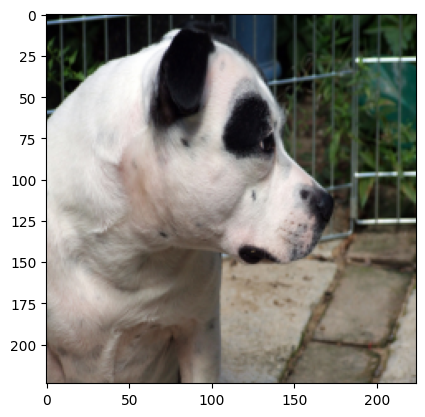

In [162]:
plt.imshow(resize(to_tensor(img)).permute(1,2,0))

`-` 이러한 변환들을 묶어서~

In [177]:
trans = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([224,224]),
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ) # 컴퓨터가 좋아하는 숫자들로
])

In [184]:
trans(train_dataset[1][0])

tensor([[[1.4343, 1.4294, 1.4296,  ..., 1.4668, 1.4403, 1.4477],
         [1.3894, 1.4275, 1.4118,  ..., 1.4435, 1.4317, 1.4450],
         [1.3850, 1.4210, 1.3853,  ..., 1.4392, 1.4208, 1.4386],
         ...,
         [1.1734, 1.2022, 1.2772,  ..., 1.3782, 1.3349, 1.2940],
         [1.2597, 1.2049, 1.2946,  ..., 1.2945, 1.2878, 1.2645],
         [1.2900, 1.2777, 1.3014,  ..., 1.3597, 1.3580, 1.3987]],

        [[1.5257, 1.5207, 1.5209,  ..., 1.4902, 1.4618, 1.4694],
         [1.4798, 1.5188, 1.5028,  ..., 1.4652, 1.4530, 1.4667],
         [1.4753, 1.5122, 1.4757,  ..., 1.4629, 1.4424, 1.4602],
         ...,
         [1.1690, 1.2003, 1.2123,  ..., 1.3672, 1.3324, 1.2880],
         [1.2507, 1.2287, 1.2662,  ..., 1.2190, 1.2052, 1.1573],
         [1.2272, 1.2403, 1.3688,  ..., 1.2989, 1.3191, 1.3493]],

        [[1.5495, 1.5445, 1.5409,  ..., 1.5134, 1.4859, 1.4934],
         [1.5037, 1.5426, 1.5263,  ..., 1.4892, 1.4771, 1.4907],
         [1.4991, 1.5349, 1.4995,  ..., 1.4858, 1.4663, 1.

`-` 모든 $i=1,2,3,\dots,n$에 대하여 `trans(train_dataset[i][0])` 를 수행하고 싶음. (for문 쓰고 싶죠?)

In [216]:
train_dataset = torchvision.datasets.OxfordIIITPet(
  root='./data', split='trainval',
  target_types="binary-category",
  transform = trans,
  download=True
)
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8,0.2])
test_dataset = torchvision.datasets.OxfordIIITPet(
  root='./data', split='test',
  target_types="binary-category",
  transform = trans,
  download=True
)

In [217]:
len(train_dataset), len(valid_dataset), len(test_dataset)

(2944, 736, 3669)

`-` 이제 "X,y --> ds --> dl --> 학습" 를 하면 될것 같다. 그렇지만 사실 (X,y), (XX,yy), (XXX,yyy)를 따로 정리할 필요는 없는데, 아래의 오브젝트들이 이미 ds이기 때문

- train_dataset
- valid_dataset
- test_dataset

## B. `ds` 만들기

In [238]:
ds_train = train_dataset
ds_val = valid_dataset
ds_test = test_dataset

## C. `dl` 만들기

In [239]:
dl_train = torch.utils.data.DataLoader(ds_train, batch_size=16, shuffle=True)
dl_val = torch.utils.data.DataLoader(ds_val, batch_size=16, shuffle=False)
dl_test = torch.utils.data.DataLoader(ds_test, batch_size=16, shuffle=False)

## D. 적합

In [204]:
net = torchvision.models.resnet18(pretrained=True)
net.fc = torch.nn.Linear(512,2)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
net.to("cuda:0")
for epoch in range(10):
    for Xm,ym in dl_train:
        Xm = Xm.to("cuda:0")
        ym = ym.to("cuda:0")
        # step1
        Logits = net(Xm)
        # step2
        loss = loss_fn(Logits,ym)
        # step3
        loss.backward()
        # step4
        optimizer.step()
        optimizer.zero_grad()
    # display
    if (epoch+1)%2 == 0:
        net.eval()
        train_acc = accuracy(net,dl_train)
        val_acc = accuracy(net,dl_val)
        print(f"epoch = {epoch+1} / train acc = {train_acc:.4f} / val acc = {val_acc:.4f}")
        net.train()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch = 2 / train acc = 0.9572 / val acc = 0.9226
epoch = 4 / train acc = 0.7014 / val acc = 0.6807
epoch = 6 / train acc = 0.9718 / val acc = 0.9348
epoch = 8 / train acc = 0.9769 / val acc = 0.9198
epoch = 10 / train acc = 0.9878 / val acc = 0.9171


In [228]:
net.eval()
accuracy(net,dl_test)

0.9144180417060852

## E. 예측

`-` 우리강아지사진 (하니)

![](https://github.com/guebin/DL2026/blob/master/imgs/hani1.jpeg?raw=true)

`-` 위의 이미지를 텐서로 만들자.

In [229]:
import requests
import io
from PIL import Image

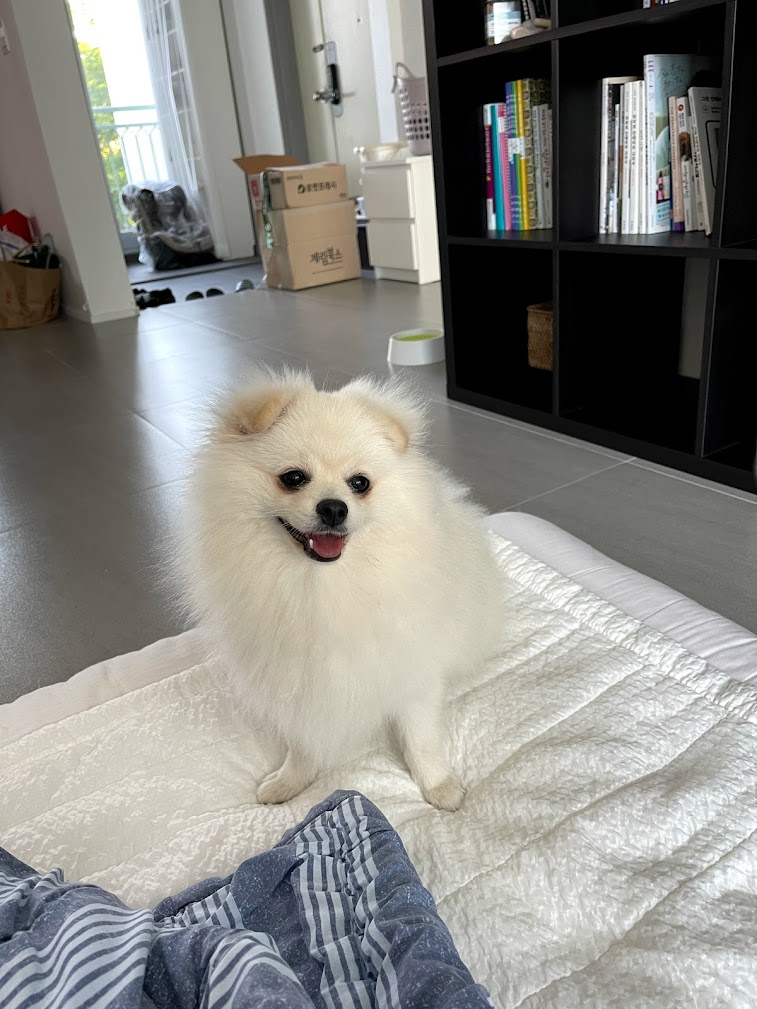

In [231]:
hani = Image.open(io.BytesIO(requests.get("https://github.com/guebin/DL2026/blob/master/imgs/hani1.jpeg?raw=true").content))
hani

In [237]:
net(trans(hani).reshape(1,3,224,224).to("cuda:0")).softmax(axis=1)

tensor([[0.0012, 0.9988]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

- 강아지라고 잘 예측함.

# 6. 크롤링

## A. 크롤링하기

In [240]:
!uv pip install --system -q ddgs

In [241]:
from pathlib import Path
import httpx
from ddgs import DDGS
import time

In [242]:
queries = {
    "taylor": [
        "Taylor Swift portrait",
        "Taylor Swift face",
        "Taylor Swift smile",
        "Taylor Swift Eras tour",
        "Taylor Swift Reputation tour",
        "Taylor Swift 1989 tour",
        "Taylor Swift Grammy",
        "Taylor Swift VMA",
        "Taylor Swift AMA",
        "Taylor Swift Billboard awards",
        "Taylor Swift red carpet",
        "Taylor Swift photoshoot",
        "Taylor Swift magazine cover",
        "Taylor Swift Vogue",
        "Taylor Swift Time magazine",
        "Taylor Swift interview",
        "Taylor Swift live performance",
        "Taylor Swift music video",
        "Taylor Swift NFL",
        "Taylor Swift Blank Space",
        "Taylor Swift Anti-Hero",
        "Taylor Swift Cruel Summer",
        "Taylor Swift Lover",
        "Taylor Swift Midnights",
        "Taylor Swift Folklore",
        "Taylor Swift Bad Blood",
    ],
    "ariana": [
        "Ariana Grande",
        "Ariana Grande portrait",
        "Ariana Grande face",
        "Ariana Grande smile",
        "Ariana Grande Sweetener tour",
        "Ariana Grande Honeymoon tour",
        "Ariana Grande Dangerous Woman tour",
        "Ariana Grande Grammy",
        "Ariana Grande VMA",
        "Ariana Grande AMA",
        "Ariana Grande Billboard awards",
        "Ariana Grande red carpet",
        "Ariana Grande photoshoot",
        "Ariana Grande magazine cover",
        "Ariana Grande Vogue",
        "Ariana Grande Wicked premiere",
        "Ariana Grande interview",
        "Ariana Grande music video",
        "Ariana Grande SNL",
        "Ariana Grande Thank U Next",
        "Ariana Grande 7 Rings",
        "Ariana Grande Side To Side",
        "Ariana Grande Into You",
        "Ariana Grande God Is A Woman",
        "Ariana Grande Positions",
        "Ariana Grande Sweetener",
        "Ariana Grande Problem",
    ],
}
target_per_class = 30
base_dir = Path.cwd() / "images"

def ddgs_search(q, retries=3):
    """매 호출마다 새 세션 + 재시도."""
    for attempt in range(retries):
        try:
            with DDGS() as ddgs:
                return list(ddgs.images(q, region="us-en", max_results=200))
        except Exception:
            time.sleep(8 + attempt * 5)
    return None


with httpx.Client(timeout=10, follow_redirects=True) as client:
    for kw, qs in queries.items():
        save_dir = base_dir / kw
        save_dir.mkdir(parents=True, exist_ok=True)
        seen, saved = set(), 0
        print(f"\n===== '{kw}' 이미지 다운로드 → {save_dir} =====")

        for q in qs:
            if saved >= target_per_class:
                break
            results = ddgs_search(q)
            if results is None:
                print(f"  '{q}': (요청 실패)")
                continue
            q_saved = 0
            for r in results:
                if saved >= target_per_class:
                    break
                url = r.get("image")
                if not url or url in seen:
                    continue
                seen.add(url)
                try:
                    resp = client.get(url, headers={"User-Agent": "Mozilla/5.0"})
                    resp.raise_for_status()
                    ext = url.split("?")[0].split(".")[-1].lower()
                    if ext not in {"jpg", "jpeg", "png", "gif", "webp"}:
                        ext = "jpg"
                    saved += 1
                    q_saved += 1
                    (save_dir / f"{kw}_{saved:03d}.{ext}").write_bytes(resp.content)
                except Exception:
                    continue
            print(f"  '{q}': +{q_saved}장 (누적 {saved})")
        print(f"{kw}: 총 {saved}장 저장 (dedup 전)")


# ===== 손상 이미지 제거 =====
for p in base_dir.rglob("*"):
    if p.is_file():
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            print(f"remove broken: {p}")
            p.unlink()


===== 'taylor' 이미지 다운로드 → /content/images/taylor =====
  'Taylor Swift portrait': +30장 (누적 30)
taylor: 총 30장 저장 (dedup 전)

===== 'ariana' 이미지 다운로드 → /content/images/ariana =====
  'Ariana Grande': +30장 (누적 30)
ariana: 총 30장 저장 (dedup 전)


## B. `ds` 만들기

In [266]:
trans = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([224,224]),
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ) # 컴퓨터가 좋아하는 숫자들로
])
ds_all = torchvision.datasets.ImageFolder(
    root = "./images",
    transform=trans
)

{'ariana': 0, 'taylor': 1}

In [273]:
ds_train, ds_val, ds_test = torch.utils.data.random_split(ds_all, [0.6,0.2,0.2])